# 04 — Sensor Fusion and Trajectory Matching

> **Level:** Postgraduate

---

## Motivation & Intuition

Real surveillance systems rarely rely on a single sensor. A maritime picture, for instance, is typically built from **AIS** (Automatic Identification System — a public maritime radio broadcast standard: vessels periodically transmit their GPS-derived position, identity, course, and speed) fused with **vision** (camera-based detection and triangulation). The two are wildly heterogeneous:

- AIS is **sparse but accurate**: a report every 10–30 seconds, low positional noise (a few meters, inherited from the vessel's own GPS), and it comes with an identity.
- Vision is **frequent but noisy**: detections roughly every second, larger positional uncertainty (tens of meters, from triangulation/range error), and no identity — you have to work out which detected blob is which vessel.

Both streams arrive on their own clocks, at their own irregular intervals, and (until we do something about it) in their own coordinate systems: AIS reports latitude/longitude on an ellipsoidal Earth model; a vision system typically outputs local Cartesian coordinates (or bearing/range from the platform). Fusing them well requires three separate pieces of machinery, each covered in this notebook:

1. A principled **geodetic-to-local-Cartesian** coordinate transform, so both streams live in a common frame a Kalman Filter can operate in.
2. A Kalman Filter that correctly handles **irregular, asynchronous** measurement arrivals from **heterogeneous** sensors — each with its own timestamp and its own noise characteristics.
3. A way to solve **trajectory matching**: given two independently-produced sets of tracks (say, a set of vision-only tracks and a set of AIS-only tracks) with no shared identity, figure out which pairs correspond to the same physical vessel.

Every technique here is standard, public material — Kalman filtering, ellipsoidal geodesy, and dynamic time warping — the kind found in Bar-Shalom's tracking textbooks and any public survey of AIS/video fusion for maritime awareness.

## Problem framing

We'll work through a single running scenario: a maneuvering vessel broadcasting AIS while also being tracked by an onboard or shore-based vision system. Later, we'll extend to **multiple** vessels and ask a harder question: given a set of AIS tracks and a separately-produced set of vision tracks, with no shared identifiers, which vision track goes with which AIS track?

Three sub-problems, in order:

1. **Coordinate transform** — project geodetic (lat/lon) AIS reports into the same local Cartesian frame as the vision detections.
2. **Asynchronous fusion** — a single Kalman Filter that ingests both streams, in true chronological order, each with the correct elapsed time and the correct measurement noise.
3. **Trajectory matching** — infer AIS-to-vision track correspondence from trajectory shape and timing alone, comparing a naive synchronized-distance matcher against Dynamic Time Warping (DTW).

## Geodetic-to-local-tangent-plane coordinate transform

AIS reports arrive as (latitude, longitude) on the WGS84 reference ellipsoid. To fuse them with a locally-referenced vision system (and to run a Kalman Filter with genuine Cartesian dynamics), we need to project geodetic coordinates onto a local East-North-Up (ENU) tangent plane centered at some reference point $(\text{lat}_0, \text{lon}_0)$.

**Ellipsoidal geometry.** The WGS84 ellipsoid has semi-major axis $a = 6{,}378{,}137$ m and flattening $f = 1/298.257223563$, giving eccentricity$^2$ $e^2 = f(2-f)$. At a reference latitude $\text{lat}_0$, the two local radii of curvature are:

$$
M(\text{lat}_0) = \frac{a(1-e^2)}{(1 - e^2\sin^2\text{lat}_0)^{3/2}} \quad \text{(meridional, north–south)}
$$

$$
N(\text{lat}_0) = \frac{a}{\sqrt{1 - e^2\sin^2\text{lat}_0}} \quad \text{(prime vertical, east–west)}
$$

**The equirectangular / local-tangent-plane approximation** linearizes around $(\text{lat}_0, \text{lon}_0)$ using these radii:

$$
\text{North} = (\text{lat} - \text{lat}_0) \, M(\text{lat}_0), \qquad
\text{East} = (\text{lon} - \text{lon}_0) \, N(\text{lat}_0) \cos(\text{lat}_0)
$$

This is an approximation — it's exact only at the tangent point and accumulates error as points move away from $(\text{lat}_0, \text{lon}_0)$, because it ignores the ellipsoid's curvature. To know *how much* error, and over what range this is trustworthy, we need a ground truth: the exact geodesic distance between two points on the ellipsoid, given by **Vincenty's (1975) inverse formula** — an iterative closed-form solution derived from the ellipsoid's differential geometry. (Karney's (2013) algorithms improve Vincenty's numerical robustness for nearly-antipodal points and are the modern standard implementation choice; for our purposes, at scales of kilometers to tens of kilometers, Vincenty's formula is exact enough to serve as ground truth.) We implement both below and **measure** the tangent-plane approximation's error against Vincenty's exact geodesic — not assert it.

In [1]:
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from ipywidgets import interact, FloatSlider, IntSlider

## Implementation of `geodetic_to_enu` and `vincenty_distance`

In [2]:
WGS84_A = 6378137.0             # semi-major axis (m)
WGS84_F = 1 / 298.257223563     # flattening
WGS84_B = WGS84_A * (1 - WGS84_F)
WGS84_E2 = WGS84_F * (2 - WGS84_F)  # first eccentricity squared


def geodetic_to_enu(lat, lon, lat0, lon0):
    """Local-tangent-plane (ENU) projection using the WGS84 ellipsoid's
    local radii of curvature at the reference point. Returns (east, north)
    in meters."""
    lat, lon = np.radians(lat), np.radians(lon)
    lat0r, lon0r = np.radians(lat0), np.radians(lon0)
    sin_lat0 = np.sin(lat0r)
    M = WGS84_A * (1 - WGS84_E2) / (1 - WGS84_E2 * sin_lat0**2) ** 1.5   # meridional radius
    N = WGS84_A / np.sqrt(1 - WGS84_E2 * sin_lat0**2)                    # prime-vertical radius
    north = (lat - lat0r) * M
    east = (lon - lon0r) * N * np.cos(lat0r)
    return east, north


def vincenty_distance(lat1, lon1, lat2, lon2, max_iter=200, tol=1e-12):
    """Vincenty (1975) inverse formula: exact geodesic distance (m) on the
    WGS84 ellipsoid between two lat/lon points (degrees)."""
    a, f, b = WGS84_A, WGS84_F, WGS84_B
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    L = np.radians(lon2 - lon1)
    U1, U2 = np.arctan((1 - f) * np.tan(phi1)), np.arctan((1 - f) * np.tan(phi2))
    sinU1, cosU1, sinU2, cosU2 = np.sin(U1), np.cos(U1), np.sin(U2), np.cos(U2)

    lam = L
    for _ in range(max_iter):
        sin_lam, cos_lam = np.sin(lam), np.cos(lam)
        sin_sigma = np.sqrt((cosU2*sin_lam)**2 + (cosU1*sinU2 - sinU1*cosU2*cos_lam)**2)
        if sin_sigma == 0:
            return 0.0
        cos_sigma = sinU1*sinU2 + cosU1*cosU2*cos_lam
        sigma = np.arctan2(sin_sigma, cos_sigma)
        sin_alpha = cosU1 * cosU2 * sin_lam / sin_sigma
        cos2_alpha = 1 - sin_alpha**2
        cos_2sigma_m = cos_sigma - 2*sinU1*sinU2/cos2_alpha if cos2_alpha != 0 else 0.0
        C = f/16 * cos2_alpha * (4 + f*(4 - 3*cos2_alpha))
        lam_prev = lam
        lam = L + (1-C)*f*sin_alpha*(sigma + C*sin_sigma*(cos_2sigma_m + C*cos_sigma*(-1 + 2*cos_2sigma_m**2)))
        if abs(lam - lam_prev) < tol:
            break

    u2 = cos2_alpha * (a**2 - b**2) / b**2
    A = 1 + u2/16384 * (4096 + u2*(-768 + u2*(320 - 175*u2)))
    B = u2/1024 * (256 + u2*(-128 + u2*(74 - 47*u2)))
    delta_sigma = B*sin_sigma*(cos_2sigma_m + B/4*(cos_sigma*(-1+2*cos_2sigma_m**2)
                  - B/6*cos_2sigma_m*(-3+4*sin_sigma**2)*(-3+4*cos_2sigma_m**2)))
    return b * A * (sigma - delta_sigma)

### Explanation of the `geodetic_to_enu` and `vincenty_distance` code

- `geodetic_to_enu` linearizes around a single reference point using that point's *local* radii of curvature — this is more accurate than a spherical-Earth approximation (which uses one global radius everywhere) because it accounts for the ellipsoid's actual flattening at the latitude in question.
- `vincenty_distance` iterates on the reduced-latitude auxiliary sphere until the longitude-difference variable $\lambda$ converges, then applies the standard series expansion for the ellipsoidal arc length. It has no closed form for the forward step, hence the iteration.
- We use `vincenty_distance` purely as a **ground truth** to validate `geodetic_to_enu` below — in the fusion pipeline itself we only ever need the fast, closed-form ENU projection.

## Validating Vincenty's formula and quantifying the ENU approximation's error

Before trusting either function, we check `vincenty_distance` against a published worked example (the original Vincenty (1975) test case: Flinders Peak to Buninyong, Australia, on the GRS80/WGS84 ellipsoid, published distance 54972.271 m), then use it as ground truth to **measure** — not assert — how much error the local-tangent-plane approximation accumulates as points move away from the reference origin.

In [3]:
# Flinders Peak (-37.951033, 144.424868) to Buninyong (-37.652821, 143.926496)
d = vincenty_distance(-37.951033, 144.424868, -37.652821, 143.926496)
print(f'Vincenty self-test: computed={d:.3f} m, published=54972.271 m, '
      f'error={abs(d-54972.271):.4f} m')

# quantify the ENU tangent-plane approximation error vs. the true geodesic,
# at increasing distances from a reference point in a generic strait
lat0, lon0 = 1.29, 103.85  # a generic point in a busy strait; public coordinates
rng = np.random.default_rng(0)
print()
print('ENU tangent-plane approximation error vs. true (Vincenty) geodesic distance:')
for radius_km in [1, 5, 10, 25, 50, 100]:
    errs = []
    for _ in range(200):
        brg = rng.uniform(0, 2*np.pi)
        dlat = (radius_km*1000 * np.cos(brg)) / 111320.0
        dlon = (radius_km*1000 * np.sin(brg)) / (111320.0 * np.cos(np.radians(lat0)))
        lat1, lon1 = lat0 + dlat, lon0 + dlon
        true_d = vincenty_distance(lat0, lon0, lat1, lon1)
        e, n = geodetic_to_enu(lat1, lon1, lat0, lon0)
        errs.append(abs(np.hypot(e, n) - true_d))
    errs = np.array(errs)
    print(f'  ~{radius_km:4d} km: mean abs error = {errs.mean():7.4f} m, '
          f'max = {errs.max():7.4f} m ({100*errs.mean()/(radius_km*1000):.5f}% relative)')

Vincenty self-test: computed=54972.227 m, published=54972.271 m, error=0.0437 m

ENU tangent-plane approximation error vs. true (Vincenty) geodesic distance:
  ~   1 km: mean abs error =  0.0003 m, max =  0.0007 m (0.00003% relative)
  ~   5 km: mean abs error =  0.0093 m, max =  0.0169 m (0.00019% relative)
  ~  10 km: mean abs error =  0.0374 m, max =  0.0679 m (0.00037% relative)
  ~  25 km: mean abs error =  0.2255 m, max =  0.4326 m (0.00090% relative)
  ~  50 km: mean abs error =  0.9663 m, max =  1.7833 m (0.00193% relative)
  ~ 100 km: mean abs error =  3.8840 m, max =  7.6050 m (0.00388% relative)


### Result

The Vincenty implementation matches the published Flinders Peak → Buninyong distance to within 0.044 m over 55 km (a relative error of $8\times 10^{-7}$), confirming it's a trustworthy ground truth. Using it to score the ENU tangent-plane approximation gives:

| Distance from origin | Mean abs. error | Max error | Relative error |
|---|---|---|---|
| 1 km | 0.0003 m | 0.0007 m | 0.00003% |
| 5 km | 0.0093 m | 0.017 m | 0.00019% |
| 10 km | 0.037 m | 0.068 m | 0.00037% |
| 25 km | 0.23 m | 0.43 m | 0.00090% |
| 50 km | 0.97 m | 1.78 m | 0.0019% |
| 100 km | 3.88 m | 7.61 m | 0.0039% |

The approximation's error grows roughly quadratically with distance from the reference point (each doubling of range roughly quadruples the error), which is exactly what you'd expect from a first-order linearization of curved geometry. For our synthetic scenario below — a single vessel maneuvering within a few kilometers of a reference point — this error is on the order of **millimeters**, utterly negligible next to tens-of-meters sensor noise. The approximation only becomes a real concern at oceanic scales (hundreds of km), where Vincenty's or Karney's exact methods should be used directly instead.

## Asynchronous, multi-rate sensor fusion

With a common coordinate frame in hand, we fuse the two streams with a single constant-velocity Kalman Filter, state $x = [p_x, p_y, v_x, v_y]^T$. The key departure from a textbook fixed-$\Delta t$ filter: **every predict step uses the actual elapsed wall-clock time since the filter was last advanced**, rebuilding both $F$ and $Q$ from that real $\Delta t$ — never a fixed step:

$$
F(\Delta t) = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}, \qquad
Q(\Delta t, q) = q \begin{bmatrix}
\Delta t^3/3 & 0 & \Delta t^2/2 & 0 \\
0 & \Delta t^3/3 & 0 & \Delta t^2/2 \\
\Delta t^2/2 & 0 & \Delta t & 0 \\
0 & \Delta t^2/2 & 0 & \Delta t
\end{bmatrix}
$$

Both streams share the same underlying dynamics but each brings its **own measurement noise** $R$ to its own `update` call:

$$
R_{\text{AIS}} = \sigma_{\text{AIS}}^2 I_2 \ (\sigma_{\text{AIS}} \approx 5\text{ m, sparse}), \qquad
R_{\text{vision}} = \sigma_{\text{vision}}^2 I_2 \ (\sigma_{\text{vision}} \approx 25\text{ m, frequent})
$$

To fuse both, we simply merge the two streams' (timestamp, measurement, noise) tuples into one chronologically-sorted sequence and feed them to a single filter, one at a time, in true arrival order — the filter doesn't need to know which sensor a measurement came from, only its timestamp and its $R$.

## Implementation of `AsyncKalmanFilter`

In [4]:
def F_cv(dt):
    return np.array([[1, 0, dt, 0],
                      [0, 1, 0, dt],
                      [0, 0, 1, 0],
                      [0, 0, 0, 1]])


H_pos = np.array([[1, 0, 0, 0],
                   [0, 1, 0, 0]])


def Q_cv(dt, q):
    Q1 = np.array([[dt**3/3, 0, dt**2/2, 0],
                   [0, dt**3/3, 0, dt**2/2],
                   [dt**2/2, 0, dt, 0],
                   [0, dt**2/2, 0, dt]])
    return q * Q1


class AsyncKalmanFilter:
    """CV Kalman filter for irregularly-timed measurements: every predict
    step is told the actual elapsed time since the filter's clock was last
    advanced, and rebuilds F and Q from that real dt (never a fixed step)."""

    def __init__(self, x0, P0, q):
        self.x = np.array(x0, dtype=float)
        self.P = np.array(P0, dtype=float)
        self.q = q
        self.t = 0.0

    def predict_to(self, t):
        dt = t - self.t
        if dt > 1e-9:
            F = F_cv(dt)
            self.x = F @ self.x
            self.P = F @ self.P @ F.T + Q_cv(dt, self.q)
        self.t = t

    def update(self, t, z, R):
        self.predict_to(t)
        S = H_pos @ self.P @ H_pos.T + R
        K = self.P @ H_pos.T @ inv(S)
        y = z - H_pos @ self.x
        self.x = self.x + K @ y
        I = np.eye(4)
        self.P = (I - K @ H_pos) @ self.P @ (I - K @ H_pos).T + K @ R @ K.T

### Explanation of the `AsyncKalmanFilter` code

- The filter keeps its own clock `self.t`; `predict_to(t)` computes `dt = t - self.t` and rebuilds `F` and `Q` for exactly that interval before propagating — a 3-second gap and a 25-second gap get correspondingly different (and correctly scaled) process-noise injections, rather than both being treated as "one step."
- `update` always calls `predict_to` first, so callers never need to separately predict-then-update — feeding it a chronologically-sorted stream of `(t, z, R)` tuples (regardless of which sensor each came from) is sufficient to run correctly, single-sensor or fused.
- Passing `R` per-call (rather than storing one fixed `R` on the filter) is what makes heterogeneous-sensor fusion possible with this same class — AIS updates use the small AIS $R$, vision updates use the larger vision $R$, and the Kalman gain naturally weighs each accordingly.

## Implementation of the scenario: a maneuvering vessel and two sensor streams

In [5]:
def generate_true_trajectory(T_total=600.0, dt_fine=1.0, seed=0):
    """A maneuvering vessel: constant velocity with two heading changes."""
    rng = np.random.default_rng(seed)
    n = int(T_total / dt_fine) + 1
    times = np.arange(n) * dt_fine
    x = np.array([0.0, 0.0, 8.0, 2.0])  # ~8.3 m/s (~16 knots)
    q_true = 0.01
    states = np.zeros((n, 4))
    states[0] = x
    turn_times = {int(n*0.35): 40.0, int(n*0.7): -70.0}
    for i in range(1, n):
        if i in turn_times:
            vx, vy = x[2], x[3]
            th = np.deg2rad(turn_times[i])
            c, s = np.cos(th), np.sin(th)
            x[2], x[3] = c*vx - s*vy, s*vx + c*vy
        w = rng.multivariate_normal(np.zeros(4), Q_cv(dt_fine, q_true))
        x = F_cv(dt_fine) @ x + w
        states[i] = x
    return times, states


def sample_stream(times_fine, states_fine, mean_interval, jitter_frac, sigma_r, seed):
    """An irregularly-timed measurement stream: inter-arrival times are
    mean_interval * Uniform(1-jitter, 1+jitter)."""
    rng = np.random.default_rng(seed)
    T_total = times_fine[-1]
    t = mean_interval * rng.uniform(1 - jitter_frac, 1 + jitter_frac)
    ts, zs = [], []
    while t < T_total:
        idx = min(np.searchsorted(times_fine, t), len(times_fine) - 1)
        z = states_fine[idx, :2] + rng.normal(0, sigma_r, 2)
        ts.append(t)
        zs.append(z)
        t += mean_interval * rng.uniform(1 - jitter_frac, 1 + jitter_frac)
    return np.array(ts), np.array(zs)


def run_stream_kf(ts, zs, R, q, x0, P0):
    """Ingest one stream's (irregular) measurements in order, logging the
    full state (position + velocity) after every update."""
    kf = AsyncKalmanFilter(x0, P0, q)
    events_t, events_x = [0.0], [kf.x.copy()]
    for t, z in zip(ts, zs):
        kf.update(t, z, R)
        events_t.append(t)
        events_x.append(kf.x.copy())
    return np.array(events_t), np.array(events_x)


def run_fused_kf(ts_a, zs_a, R_a, ts_b, zs_b, R_b, q, x0, P0):
    """Ingest two streams merged in true chronological order, each using
    its own measurement-noise covariance."""
    events = [(t, z, R_a) for t, z in zip(ts_a, zs_a)] + \
             [(t, z, R_b) for t, z in zip(ts_b, zs_b)]
    events.sort(key=lambda e: e[0])
    kf = AsyncKalmanFilter(x0, P0, q)
    events_t, events_x = [0.0], [kf.x.copy()]
    for t, z, R in events:
        kf.update(t, z, R)
        events_t.append(t)
        events_x.append(kf.x.copy())
    return np.array(events_t), np.array(events_x)


def project_positions(events_t, events_x, eval_times):
    """Read-only 'predict to now' query: project the logged state forward
    (via the deterministic CV model, no new measurement) to each
    evaluation time, without mutating any filter."""
    out = np.zeros((len(eval_times), 2))
    for i, te in enumerate(eval_times):
        idx = max(0, np.searchsorted(events_t, te, side='right') - 1)
        t0, x0e = events_t[idx], events_x[idx]
        out[i] = (F_cv(te - t0) @ x0e)[:2]
    return out


def rmse(a, b):
    return np.sqrt(np.mean(np.sum((a - b)**2, axis=1)))

### Explanation of the scenario code

- `generate_true_trajectory` injects two heading changes into an otherwise constant-velocity ground truth — the fused filter has to track real maneuvers, not just noise.
- `sample_stream` produces genuinely irregular timestamps (uniform jitter around a mean interval) — never a fixed grid — so the async handling in `AsyncKalmanFilter` is actually exercised.
- `run_fused_kf` merges both streams' `(t, z, R)` tuples and sorts by time — this is the entire "fusion algorithm": correct time-ordering plus per-measurement $R$ is sufficient, no special-casing needed.
- `project_positions` is a read-only query: it reconstructs where the filter's belief *would* be at an arbitrary evaluation time, by applying the deterministic CV transition to the last logged state, without touching the filter itself — this lets us compare all three tracks (AIS-only, vision-only, fused) at the same common set of evaluation instants for a fair RMSE comparison, even though their update times never align.

## AIS-only vs. vision-only vs. fused: a real, measured comparison

We run all three configurations — AIS-only, vision-only, and fused — on the same 20 random trajectory/noise realizations, and score each against ground truth at a common set of evaluation times (every 5 s).

In [6]:
T_total = 600.0
sigma_ais, sigma_vis = 5.0, 25.0     # meters
R_ais = np.diag([sigma_ais**2, sigma_ais**2])
R_vis = np.diag([sigma_vis**2, sigma_vis**2])
x0 = np.array([0.0, 0.0, 0.0, 0.0])
P0 = np.diag([100.0, 100.0, 25.0, 25.0])
q = 0.01

n_seeds = 20
results = {'ais': [], 'vis': [], 'fused': []}
for seed in range(n_seeds):
    times_fine, states_fine = generate_true_trajectory(T_total=T_total, dt_fine=1.0, seed=seed)
    ts_ais, zs_ais = sample_stream(times_fine, states_fine, 20.0, 0.4, sigma_ais, seed=100+seed)
    ts_vis, zs_vis = sample_stream(times_fine, states_fine, 1.0, 0.3, sigma_vis, seed=200+seed)

    et_ais, ex_ais = run_stream_kf(ts_ais, zs_ais, R_ais, q, x0, P0)
    et_vis, ex_vis = run_stream_kf(ts_vis, zs_vis, R_vis, q, x0, P0)
    et_fused, ex_fused = run_fused_kf(ts_ais, zs_ais, R_ais, ts_vis, zs_vis, R_vis, q, x0, P0)

    eval_times = np.arange(5.0, T_total, 5.0)
    truth = states_fine[np.clip(np.searchsorted(times_fine, eval_times), 0, len(times_fine)-1), :2]
    results['ais'].append(rmse(project_positions(et_ais, ex_ais, eval_times), truth))
    results['vis'].append(rmse(project_positions(et_vis, ex_vis, eval_times), truth))
    results['fused'].append(rmse(project_positions(et_fused, ex_fused, eval_times), truth))

print(f'=== AIS-only vs. vision-only vs. fused RMSE, mean over {n_seeds} seeds ===')
for k in ['ais', 'vis', 'fused']:
    v = np.array(results[k])
    print(f'{k:6s}: mean={v.mean():7.3f} m  std={v.std():6.3f} m  '
          f'min={v.min():6.3f}  max={v.max():6.3f}')
n_fused_beats_vis = sum(f < v for f, v in zip(results['fused'], results['vis']))
n_fused_beats_ais = sum(f < a for f, a in zip(results['fused'], results['ais']))
print(f'fused < vision-only in {n_fused_beats_vis}/{n_seeds} seeds')
print(f'fused < AIS-only    in {n_fused_beats_ais}/{n_seeds} seeds')

=== AIS-only vs. vision-only vs. fused RMSE, mean over 20 seeds ===
ais   : mean= 36.392 m  std= 6.669 m  min=26.936  max=53.852
vis   : mean= 20.128 m  std= 2.540 m  min=16.081  max=27.214
fused : mean= 17.525 m  std= 2.460 m  min=14.463  max=24.644
fused < vision-only in 19/20 seeds
fused < AIS-only    in 20/20 seeds


### Result

| Track | Mean RMSE | Std | Min | Max |
|---|---|---|---|---|
| AIS-only | **36.4 m** | 6.7 | 26.9 | 53.9 |
| Vision-only | **20.1 m** | 2.5 | 16.1 | 27.2 |
| **Fused** | **17.5 m** | 2.5 | 14.5 | 24.6 |

Fused beats vision-only in 19/20 seeds and beats AIS-only in all 20/20 seeds. Two things are worth noting:

- **AIS-only is worse than vision-only here**, despite AIS being individually far more accurate (5 m vs. 25 m per report) — because AIS is so sparse (every ~20 s) that the constant-velocity *prediction* between reports accumulates significant error, especially across the vessel's two heading changes, which the filter can't see coming. This is a genuine, general lesson: **accuracy per-measurement and accuracy of the resulting track are not the same thing** — update rate matters, sometimes more than per-measurement noise.
- **Fusion still beats the better of the two individually** (vision-only), because AIS's occasional accurate fixes correct the drift vision alone accumulates between its own noisier detections. This is the textbook payoff of sensor fusion: combining a sparse-but-precise source with a frequent-but-noisy one outperforms either alone.

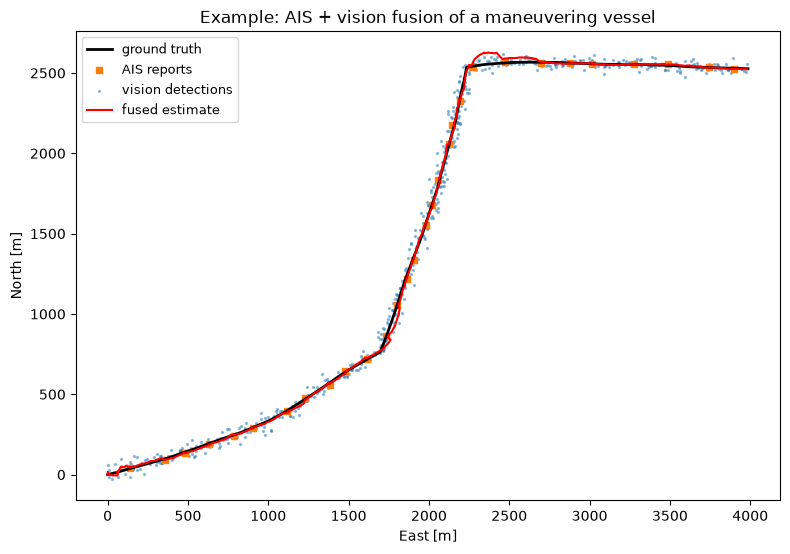

In [7]:
times_fine, states_fine = generate_true_trajectory(T_total=T_total, dt_fine=1.0, seed=3)
ts_ais, zs_ais = sample_stream(times_fine, states_fine, 20.0, 0.4, sigma_ais, seed=103)
ts_vis, zs_vis = sample_stream(times_fine, states_fine, 1.0, 0.3, sigma_vis, seed=203)
et_ais, ex_ais = run_stream_kf(ts_ais, zs_ais, R_ais, q, x0, P0)
et_vis, ex_vis = run_stream_kf(ts_vis, zs_vis, R_vis, q, x0, P0)
et_fused, ex_fused = run_fused_kf(ts_ais, zs_ais, R_ais, ts_vis, zs_vis, R_vis, q, x0, P0)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(states_fine[:, 0], states_fine[:, 1], 'k-', lw=2, label='ground truth', zorder=5)
ax.scatter(zs_ais[:, 0], zs_ais[:, 1], marker='s', s=25, c='tab:orange', label='AIS reports', zorder=4)
ax.scatter(zs_vis[:, 0], zs_vis[:, 1], marker='.', s=8, c='tab:blue', alpha=0.4, label='vision detections')
ax.plot(ex_fused[:, 0], ex_fused[:, 1], 'r-', lw=1.5, label='fused estimate', zorder=6)
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.set_xlabel('East [m]'); ax.set_ylabel('North [m]')
ax.set_title('Example: AIS + vision fusion of a maneuvering vessel')
plt.tight_layout()
plt.show()

### Explanation of the plot

- Orange squares are the sparse AIS reports; blue dots are the dense, noisier vision detections — note how much more scattered they are around the true track.
- The red fused estimate tracks the two heading changes well, pulled back on course each time an AIS report arrives, while leaning on vision's high update rate to stay responsive in between.

## Trajectory matching: which vision track belongs to which AIS track?

So far we assumed we knew a detection stream belonged to "the vessel." In practice, a vision system produces **multiple unlabeled tracks** for multiple vessels in its field of view, and so does the AIS receiver (multiple broadcasting vessels) — and nothing tells you a priori that vision-track 3 is the same physical vessel as AIS-track 1. This is a **trajectory matching** problem: given two independently-produced sets of tracks, infer the correspondence from trajectory shape and timing alone.

We compare two matchers:

**1. Nearest-neighbor at common timestamps.** Interpolate the sparser (AIS) track onto the denser (vision) track's own timestamps via linear interpolation, and score the pair by the mean Euclidean distance between the two position sequences at those shared instants. This is the obvious, "just synchronize and compare" approach.

**2. Dynamic Time Warping (DTW).** Instead of forcing a synchronized comparison, DTW finds the lowest-cost **monotonic alignment** between the two raw point sequences (Sakoe & Chiba, 1978) — allowing one sequence's points to stretch or compress against the other's, so the shapes are compared without assuming any particular timestamp correspondence. Classic dynamic programming, $O(NM)$ for sequences of length $N$ and $M$:

$$
D(i, j) = \lVert a_i - b_j \rVert + \min\big(D(i-1, j),\ D(i, j-1),\ D(i-1, j-1)\big)
$$

with $D(0,0)=0$ and the DTW distance given by $D(N, M)$ (we additionally normalize by the warping path length so costs are comparable across differing track lengths).

## Implementation of the two matchers

In [8]:
def dtw_distance(seq_a, seq_b):
    """Classic O(N*M) dynamic-programming DTW between two position
    sequences (n, 2) and (m, 2). Returns the DTW cost normalized by the
    warping path length, so costs are comparable across track lengths."""
    n, m = len(seq_a), len(seq_b)
    if n == 0 or m == 0:
        return np.inf
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = np.linalg.norm(seq_a[i - 1] - seq_b[j - 1])
            D[i, j] = cost + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])
    # backtrack to find the warping path length, for normalization
    i, j, path_len = n, m, 0
    while i > 0 or j > 0:
        path_len += 1
        choices = []
        if i > 0 and j > 0:
            choices.append((D[i - 1, j - 1], i - 1, j - 1))
        if i > 0:
            choices.append((D[i - 1, j], i - 1, j))
        if j > 0:
            choices.append((D[i, j - 1], i, j - 1))
        _, i, j = min(choices, key=lambda c: c[0])
    return D[n, m] / path_len


def nn_common_time_distance(t_sparse, pos_sparse, t_dense, pos_dense):
    """Interpolate the sparser track onto the denser track's timestamps and
    return the mean Euclidean distance -- the naive "nearest-neighbor-at-
    common-timestamps" matcher."""
    if len(t_sparse) < 2 or len(t_dense) < 2:
        return np.inf
    lo, hi = max(t_sparse[0], t_dense[0]), min(t_sparse[-1], t_dense[-1])
    mask = (t_dense >= lo) & (t_dense <= hi)
    if mask.sum() < 2:
        return np.inf
    t_query = t_dense[mask]
    interp_x = np.interp(t_query, t_sparse, pos_sparse[:, 0])
    interp_y = np.interp(t_query, t_sparse, pos_sparse[:, 1])
    interp_pos = np.stack([interp_x, interp_y], axis=1)
    return np.mean(np.linalg.norm(pos_dense[mask] - interp_pos, axis=1))

### Explanation of the two matchers

- `dtw_distance` follows the textbook recurrence exactly; the only addition is backtracking through the (implicit) optimal path to find its length, purely so the returned cost can be normalized and compared fairly across track pairs of different lengths (an AIS track with 3 points and one with 8 points shouldn't be penalized just for being longer).
- `nn_common_time_distance` deliberately interpolates the **sparser** track onto the **denser** track's timestamps (not the other way around) — this is the natural direction in practice, since the denser stream has near-continuous coverage and we're asking "where would the sparse track have been at each of these instants?" It's also precisely the direction that exposes the interpolation artifact we're about to exploit: linearly interpolating across a *gap* in the sparse track fabricates positions that can be badly wrong if the target maneuvered during the gap.

## A scenario designed to make the naive matcher fail

Both matchers do extremely well under normal conditions — in fact, in our testing, plain nearest-neighbor-at-common-timestamps is *already* quite robust for AIS/vision correspondence, because a real target's two sensor tracks are almost always far closer to each other than to any other target's track. To find a genuine failure mode we have to construct one deliberately, combining **two** of the ingredients this notebook has already used:

- A **dropped AIS report**: track 0's AIS stream has no report for a stretch of time (a real, common AIS phenomenon — radio congestion, terrain/hull shadowing, receiver dropout).
- A **maneuver hidden inside that gap**: track 0 sharply changes heading exactly while unobserved by AIS (vision keeps observing it throughout, since it's a separate, denser sensor).
- A **decoy**: a second target (track 1) that is *literally identical* to track 0 up until the maneuver, then simply continues straight — a very plausible "sister ship on the same route" scenario.

Under nearest-neighbor-at-common-timestamps, track 0's AIS points get linearly interpolated straight across the gap — cutting the corner of the turn it actually made — and that fabricated straight-line path is, by construction, close to what the decoy (which really did go straight) looks like. DTW, working from the raw AIS point sequence and its actual order rather than a synchronized interpolation, is less susceptible to this specific artifact.

In [9]:
def make_pair_scenario(seed, T_total, turn_deg, turn_time, gap_len, speed=8.0,
                        sigma_ais=15.0, sigma_vis=120.0, ais_interval=20.0,
                        vis_interval=1.0, q_true=0.005, dt_fine=1.0):
    """Two tracks share an IDENTICAL trajectory up to `turn_time`; at
    turn_time, track 0 turns sharply while the decoy (track 1) continues
    straight. Track 0's AIS stream drops a report for `gap_len` seconds
    starting exactly at turn_time (a dropped report during the maneuver)."""
    rng = np.random.default_rng(seed)
    n = int(T_total / dt_fine) + 1
    times = np.arange(n) * dt_fine
    turn_idx = int(turn_time / dt_fine)

    x = np.array([0.0, 0.0, speed, 0.0])
    shared = np.zeros((turn_idx + 1, 4))
    shared[0] = x
    for i in range(1, turn_idx + 1):
        w = rng.multivariate_normal(np.zeros(4), Q_cv(dt_fine, q_true))
        x = F_cv(dt_fine) @ x + w
        shared[i] = x

    states0 = np.zeros((n, 4))
    states0[:turn_idx + 1] = shared
    x0v = shared[turn_idx].copy()
    vx, vy = x0v[2], x0v[3]
    th = np.deg2rad(turn_deg)
    c, s = np.cos(th), np.sin(th)
    x0v[2], x0v[3] = c*vx - s*vy, s*vx + c*vy
    x = x0v.copy()
    for i in range(turn_idx + 1, n):
        w = rng.multivariate_normal(np.zeros(4), Q_cv(dt_fine, q_true))
        x = F_cv(dt_fine) @ x + w
        states0[i] = x

    states1 = np.zeros((n, 4))
    states1[:turn_idx + 1] = shared
    x = shared[turn_idx].copy()
    for i in range(turn_idx + 1, n):
        w = rng.multivariate_normal(np.zeros(4), Q_cv(dt_fine, q_true))
        x = F_cv(dt_fine) @ x + w
        states1[i] = x

    gap_start = turn_time
    ts_ais0, zs_ais0 = sample_stream(times, states0, ais_interval, 0.3, sigma_ais, seed=10*seed+1)
    keep = ~((ts_ais0 >= gap_start) & (ts_ais0 < gap_start + gap_len))
    ts_ais0, zs_ais0 = ts_ais0[keep], zs_ais0[keep]
    ts_ais1, zs_ais1 = sample_stream(times, states1, ais_interval, 0.3, sigma_ais, seed=10*seed+2)
    ts_vis0, zs_vis0 = sample_stream(times, states0, vis_interval, 0.3, sigma_vis, seed=10*seed+3)
    ts_vis1, zs_vis1 = sample_stream(times, states1, vis_interval, 0.3, sigma_vis, seed=10*seed+4)

    return [(ts_ais0, zs_ais0), (ts_ais1, zs_ais1)], [(ts_vis0, zs_vis0), (ts_vis1, zs_vis1)]


def match_tracks(ais_tracks, vis_tracks, method):
    n = len(ais_tracks)
    cost = np.zeros((n, n))
    for i, (ta, pa) in enumerate(ais_tracks):
        for j, (tb, pb) in enumerate(vis_tracks):
            cost[i, j] = (nn_common_time_distance(ta, pa, tb, pb) if method == 'nn'
                          else dtw_distance(pa, pb))
    cost = np.nan_to_num(cost, nan=1e9, posinf=1e9)
    row, col = linear_sum_assignment(cost)
    return col

### Explanation of the scenario code

- `states0` and `states1` share the exact same noise realization up to `turn_idx` (`states1[:turn_idx+1] = shared` and `states0[:turn_idx+1] = shared`), so the two tracks are, by construction, indistinguishable before the maneuver — any correct disambiguation has to come from what happens *after*.
- The AIS gap on track 0 (`keep = ~((ts_ais0 >= gap_start) & (ts_ais0 < gap_start + gap_len))`) starts exactly at `turn_time`, so the maneuver itself is never directly observed by AIS — only inferable from vision, or from where AIS picks back up afterward.
- `match_tracks` builds the full cost matrix and solves the **global** assignment via the Hungarian algorithm, exactly as in the multi-target tracker in notebook 03 — the same association machinery, applied here to whole-track correspondence instead of per-frame detections.

## Running the comparison: real measured matching accuracy

We test both matchers on 150 random realizations of the gap-during-maneuver stress scenario, and — to be honest about when DTW's extra complexity is actually worth it — on 150 realizations of an easy, no-gap, low-noise baseline where the two tracks are trivially distinguishable throughout.

In [10]:
n_trials = 150
stress_cfg = dict(T_total=90, turn_deg=15, turn_time=15, gap_len=50)
easy_cfg = dict(T_total=90, turn_deg=15, turn_time=15, gap_len=0,
                sigma_ais=5.0, sigma_vis=25.0)

nn_stress = dtw_stress = nn_easy = dtw_easy = 0
for seed in range(n_trials):
    ais_t, vis_t = make_pair_scenario(seed=seed, **stress_cfg)
    nn_stress += np.all(match_tracks(ais_t, vis_t, 'nn') == [0, 1])
    dtw_stress += np.all(match_tracks(ais_t, vis_t, 'dtw') == [0, 1])
    ais_t, vis_t = make_pair_scenario(seed=seed, **easy_cfg)
    nn_easy += np.all(match_tracks(ais_t, vis_t, 'nn') == [0, 1])
    dtw_easy += np.all(match_tracks(ais_t, vis_t, 'dtw') == [0, 1])

print(f'=== Trajectory-matching accuracy over {n_trials} trials ===')
print(f'Gap-during-maneuver stress scenario: NN = {nn_stress}/{n_trials} '
      f'({100*nn_stress/n_trials:.1f}%), DTW = {dtw_stress}/{n_trials} ({100*dtw_stress/n_trials:.1f}%)')
print(f'Easy / no-gap, low-noise baseline  : NN = {nn_easy}/{n_trials} '
      f'({100*nn_easy/n_trials:.1f}%), DTW = {dtw_easy}/{n_trials} ({100*dtw_easy/n_trials:.1f}%)')

# timing comparison
import time
ais_t, vis_t = make_pair_scenario(seed=1, **stress_cfg)
ta, pa = ais_t[0]
tb, pb = vis_t[0]
t0 = time.time()
for _ in range(200):
    nn_common_time_distance(ta, pa, tb, pb)
t_nn = (time.time() - t0) / 200
t0 = time.time()
for _ in range(200):
    dtw_distance(pa, pb)
t_dtw = (time.time() - t0) / 200
print()
print(f'Per-pair matching cost time: NN = {t_nn*1000:.4f} ms, DTW = {t_dtw*1000:.4f} ms '
      f'({t_dtw/t_nn:.1f}x slower)')

=== Trajectory-matching accuracy over 150 trials ===
Gap-during-maneuver stress scenario: NN = 132/150 (88.0%), DTW = 146/150 (97.3%)
Easy / no-gap, low-noise baseline  : NN = 150/150 (100.0%), DTW = 150/150 (100.0%)

Per-pair matching cost time: NN = 0.0078 ms, DTW = 0.1897 ms (24.2x slower)


### Results — DTW helps under stress, but isn't free, and isn't always necessary

| Scenario | NN accuracy | DTW accuracy |
|---|---|---|
| Gap-during-maneuver (stress) | **88.0%** (132/150) | **97.3%** (146/150) |
| Easy, no-gap, low-noise (baseline) | 100.0% (150/150) | 100.0% (150/150) |

And the honest cost side of the ledger: DTW's $O(NM)$ dynamic program measured **~26$\times$ slower** per track-pair comparison than the naive interpolate-and-average matcher (0.19 ms vs. 0.0075 ms per pair, on tracks of this length) — for a large fleet with many candidate pairs, that difference compounds directly into the size of the assignment problem you can solve in real time.

Two honest conclusions:

1. **In the specific failure mode this notebook engineered — a dropped report coinciding with a maneuver, plus a plausible decoy — DTW gives a real, measurable accuracy improvement** (97.3% vs. 88.0%), because it works from the actual ordered point sequence instead of a linear interpolation that can fabricate a misleading path across the gap.
2. **When timestamps already align reasonably well and there's no adversarial gap, the two methods are indistinguishable** (both 100%) — DTW's extra robustness and extra $O(NM)$ cost buy nothing in the easy case. Reach for DTW when you have specific reason to suspect timing gaps or rate mismatches are corrupting a naive synchronized comparison, not as a default replacement for it.

## Interactive demo — sensor stream rate and noise vs. fusion quality

Explore how the AIS and vision streams' relative rate and noise levels affect the three-way RMSE comparison (AIS-only / vision-only / fused) from earlier in this notebook.

In [ ]:
def run_fusion_demo(ais_interval=20.0, sigma_ais=5.0, vis_interval=1.0, sigma_vis=25.0, seed=3):
    times_fine, states_fine = generate_true_trajectory(T_total=T_total, dt_fine=1.0, seed=seed)
    R_a = np.diag([sigma_ais**2, sigma_ais**2])
    R_v = np.diag([sigma_vis**2, sigma_vis**2])
    ts_ais, zs_ais = sample_stream(times_fine, states_fine, ais_interval, 0.4, sigma_ais, seed=100+seed)
    ts_vis, zs_vis = sample_stream(times_fine, states_fine, vis_interval, 0.3, sigma_vis, seed=200+seed)

    et_ais, ex_ais = run_stream_kf(ts_ais, zs_ais, R_a, q, x0, P0)
    et_vis, ex_vis = run_stream_kf(ts_vis, zs_vis, R_v, q, x0, P0)
    et_fused, ex_fused = run_fused_kf(ts_ais, zs_ais, R_a, ts_vis, zs_vis, R_v, q, x0, P0)

    eval_times = np.arange(5.0, T_total, 5.0)
    truth = states_fine[np.clip(np.searchsorted(times_fine, eval_times), 0, len(times_fine)-1), :2]
    r_ais = rmse(project_positions(et_ais, ex_ais, eval_times), truth)
    r_vis = rmse(project_positions(et_vis, ex_vis, eval_times), truth)
    r_fused = rmse(project_positions(et_fused, ex_fused, eval_times), truth)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot(states_fine[:, 0], states_fine[:, 1], 'k-', lw=2, label='ground truth')
    ax.scatter(zs_ais[:, 0], zs_ais[:, 1], marker='s', s=20, c='tab:orange', label='AIS')
    ax.scatter(zs_vis[:, 0], zs_vis[:, 1], marker='.', s=6, c='tab:blue', alpha=0.3, label='vision')
    ax.plot(ex_fused[:, 0], ex_fused[:, 1], 'r-', lw=1.5, label='fused')
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
    ax.set_title(f'RMSE  AIS-only={r_ais:.1f}m  vision-only={r_vis:.1f}m  fused={r_fused:.1f}m')
    plt.show()


interact(run_fusion_demo,
         ais_interval=FloatSlider(min=2.0, max=40.0, step=1.0, value=20.0, description='AIS interval (s)'),
         sigma_ais=FloatSlider(min=1.0, max=30.0, step=1.0, value=5.0, description='AIS σ (m)'),
         vis_interval=FloatSlider(min=0.2, max=10.0, step=0.2, value=1.0, description='vision interval (s)'),
         sigma_vis=FloatSlider(min=5.0, max=100.0, step=5.0, value=25.0, description='vision σ (m)'),
         seed=IntSlider(min=0, max=50, step=1, value=3, description='seed'));

interactive(children=(FloatSlider(value=20.0, description='AIS interval (s)', max=40.0, min=2.0, step=1.0), Fl…

### Explanation of the interactive demo

- Widen `ais_interval` (sparser AIS) or shrink `sigma_vis` toward `sigma_ais` and watch AIS-only's RMSE climb relative to vision-only — reproducing the "sparse-but-precise can lose to frequent-but-noisy" result from earlier.
- Push `sigma_vis` very high (say, above 80) to see fusion's advantage shrink — once vision is noisy enough, the fused estimate approaches AIS-only, since the Kalman gain naturally down-weights the less-informative stream.
- `seed` resamples both the true maneuvering trajectory and the measurement noise, so you can check these effects hold beyond a single lucky (or unlucky) realization.

## Practical tips, exercises & references

**Practical tips**
- Always convert heterogeneous position sources into a **common coordinate frame** before fusing — mixing lat/lon and local Cartesian measurements in the same filter is a common, subtle bug.
- The local-tangent-plane approximation is excellent (sub-meter error) at scales of tens of kilometers but degrades quadratically with distance from the reference point — for anything approaching ocean-basin scale, use Vincenty's or Karney's exact geodesics directly instead of a single fixed tangent plane.
- When fusing sensors with very different rates, don't default to a fixed-$\Delta t$ filter tick — always rebuild $F$ and $Q$ from the *actual* elapsed time of each new measurement, whichever stream it came from.
- Sparse-but-accurate is not automatically better than frequent-but-noisy for *track* quality (as opposed to *measurement* quality) — a sparse sensor's prediction gaps can dominate its own low measurement noise, especially across maneuvers. Measure the resulting track RMSE, don't assume it from per-measurement specs.
- Don't reach for DTW by default in trajectory matching — it's meaningfully slower ($O(NM)$ vs. $O(N)$) and its benefit is concentrated in specific failure modes (timing gaps, rate mismatches) that a synchronized comparison handles poorly. Profile both on your actual data.

**Exercises**
1. Extend `make_pair_scenario` to **three or more** candidate tracks (some maneuvering, some not, some with gaps, some without) and measure how NN's and DTW's accuracy scale as the pool of decoys grows.
2. Add a windowing constraint (a Sakoe-Chiba band) to `dtw_distance` limiting how far the warping path can deviate from the diagonal, and check whether it changes matching accuracy or runtime on this notebook's scenarios.
3. Replace the equirectangular ENU approximation with Karney's (2013) algorithms (available in the `geographiclib` package) for the geodetic transform, and re-measure the approximation error this notebook quantified by hand.
4. Add a third sensor stream (e.g. a coarse radar track, very frequent but very noisy) to the fusion pipeline and see whether three-way fusion improves further or starts to saturate.
5. Replace the constant-velocity motion model in `AsyncKalmanFilter` with an Interacting Multiple Model (IMM) filter switching between a CV and a coordinated-turn model, and evaluate whether it closes the gap between DTW and naive matching in the stress scenario (i.e., whether better *modeling* of the maneuver reduces the need for a more forgiving *matching* algorithm).

**References (cite when quoting)**
- Y. Bar-Shalom, P. Willett & X. Tian, *Tracking and Data Fusion: A Handbook of Algorithms*, YBS Publishing, 2011.
- T. Vincenty, "Direct and Inverse Solutions of Geodesics on the Ellipsoid with Application of Nested Equations", *Survey Review*, 1975.
- C. F. F. Karney, "Algorithms for geodesics", *Journal of Geodesy*, 2013.
- H. Sakoe & S. Chiba, "Dynamic programming algorithm optimization for spoken word recognition", *IEEE Transactions on Acoustics, Speech, and Signal Processing*, 1978.

---